<a href="https://colab.research.google.com/github/R4F4I/semester-5-FAST-K240009/blob/main/ML-LAB/notebooks/notebookbc900e7019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e8_path = kagglehub.competition_download('playground-series-s6e8')

print('Data source import complete.')


Data source import complete.


In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [12]:
! ls /root/.cache/kagglehub/competitions/playground-series-s6e8

sample_submission.csv  test.csv  train.csv


# 1. EDA

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
train_df = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/train.csv')
test_df = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/test.csv')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1.1. Data Overview & Missing Values

In [14]:
print("--- Train Summary ---")
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape:  {test_df.shape}")

# Missing values check
missing_train = train_df.isnull().sum()[train_df.isnull().sum() > 0]
print("\nMissing values in Train:\n", missing_train if not missing_train.empty else "None")

# Check data types
train_df.info()

--- Train Summary ---
Train Shape: (691369, 14)
Test Shape:  (296302, 13)

Missing values in Train:
 age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 

## 1.2. Target Variable Analysis (addicted_label)

Target Class Distribution (%):
 addicted_label
1    70.942435
0    29.057565
Name: proportion, dtype: float64


/tmp/ipykernel_1620/3029320627.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='addicted_label', palette='viridis')


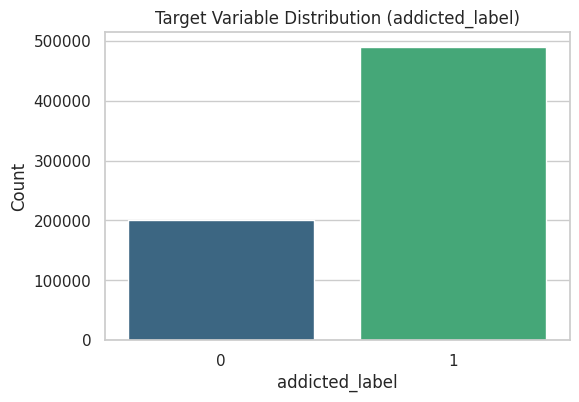

In [15]:
# Check class balance
target_counts = train_df['addicted_label'].value_counts(normalize=True) * 100
print("Target Class Distribution (%):\n", target_counts)

# Visualizing target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='addicted_label', palette='viridis')
plt.title('Target Variable Distribution (addicted_label)')
plt.ylabel('Count')
plt.show()

## 1.3. Numerical Feature Distributions & Summary

In [16]:
# Statistical summary for key numerical fields
num_cols = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

display(train_df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])

,mean,std,min,50%,max
age,26.615408,5.153162,18.00,27.00,35.00
daily_screen_time_hours,7.640865,2.721446,0.50,7.77,15.00
social_media_hours,2.471038,1.316137,0.00,2.31,8.00
gaming_hours,1.459265,0.934552,0.00,1.33,4.00
work_study_hours,2.366971,1.258797,0.00,2.20,6.00
sleep_hours,6.804334,1.234512,4.50,6.80,9.00
notifications_per_day,145.894900,65.917556,20.00,150.00,250.00
app_opens_per_day,102.636781,48.093970,15.00,104.00,180.00
weekend_screen_time,9.479866,2.856006,0.51,9.58,17.56


## 1.4. Domain Sanity Checks & Feature Interactions

In [17]:
# 1. Screen Time Consistency: Total category hours vs. Daily screen time
train_df['screen_time_subtotal'] = train_df['social_media_hours'] + train_df['gaming_hours'] + train_df['work_study_hours']
train_df['screen_time_diff'] = train_df['daily_screen_time_hours'] - train_df['screen_time_subtotal']

print("Screen time subtotal summary:")
print(train_df[['daily_screen_time_hours', 'screen_time_subtotal', 'screen_time_diff']].describe())

# 2. Total active hours vs. 24 hours
train_df['total_logged_hours'] = train_df['daily_screen_time_hours'] + train_df['sleep_hours']
print(f"\nMax logged daily hours (Screen + Sleep): {train_df['total_logged_hours'].max():.2f} hours")

Screen time subtotal summary:
       daily_screen_time_hours  screen_time_subtotal  screen_time_diff
count            595515.000000         451825.000000     421427.000000
mean                  7.640865              6.295986          1.342654
std                   2.721446              2.199842          1.480499
min                   0.500000              0.010000          0.000000
25%                   5.480000              4.630000          0.460000
50%                   7.770000              6.250000          0.750000
75%                   9.840000              7.960000          1.460000
max                  15.000000             14.560000         11.530000

Max logged daily hours (Screen + Sleep): 20.01 hours


## 1.5. Feature Correlation with Target

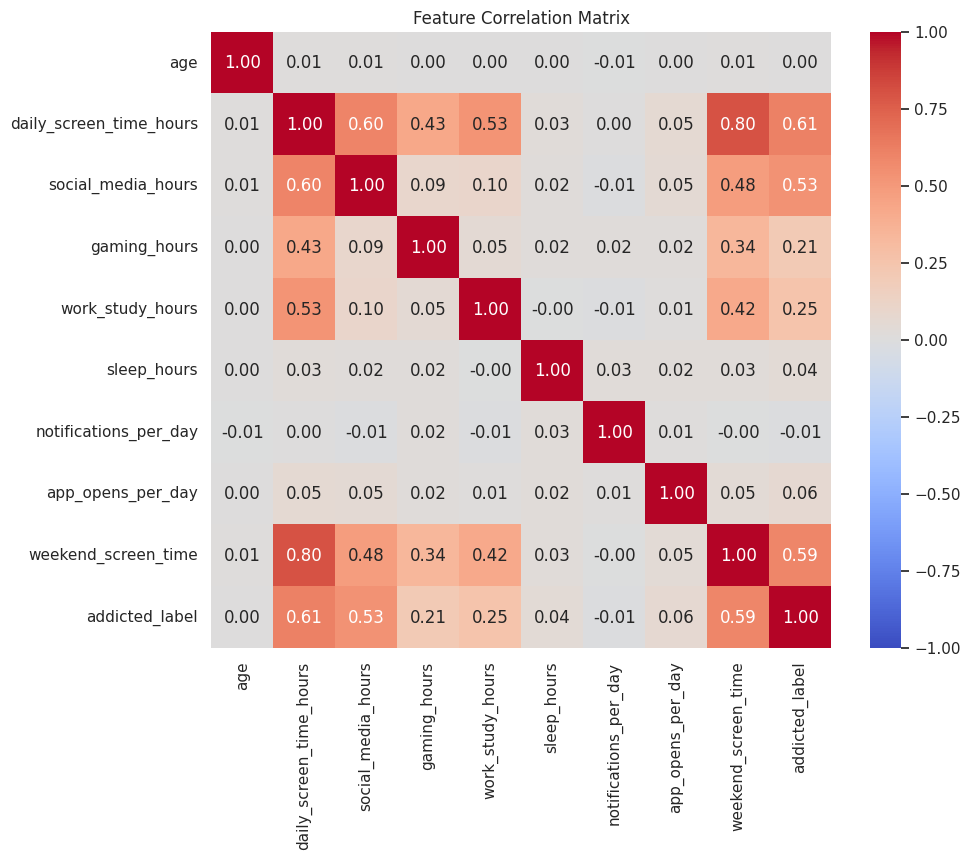

In [18]:
# Compute correlation matrix for numeric columns
plt.figure(figsize=(10, 8))
corr = train_df[num_cols + ['addicted_label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

In [19]:
train_df['social_share'] = train_df['social_media_hours'] / (train_df['daily_screen_time_hours'] + 1e-5)
train_df['recreation_to_work'] = (train_df['social_media_hours'] + train_df['gaming_hours']) / (train_df['work_study_hours'] + 1e-5)
train_df['weekend_intensity'] = train_df['weekend_screen_time'] - train_df['daily_screen_time_hours']

## 1.6. Categorical Feature Relationships

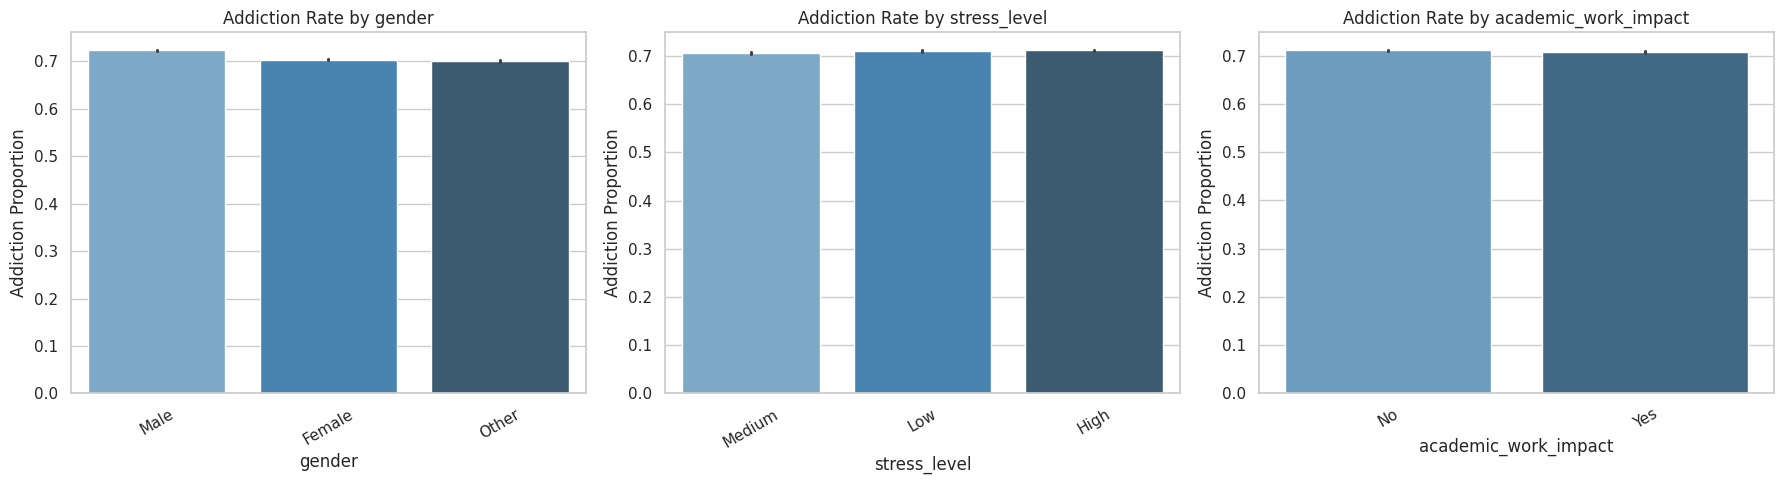

In [20]:
cat_cols = ['gender', 'stress_level', 'academic_work_impact']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    sns.barplot(
        data=train_df,
        x=col,
        y='addicted_label',
        hue=col,
        legend=False,
        ax=axes[i],
        palette='Blues_d'
    )
    axes[i].set_title(f'Addiction Rate by {col}')
    axes[i].set_ylabel('Addiction Proportion')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 1.7. Handling Missing Values

In [21]:
# Missingness ranges 4%-19% across numeric cols and ~4-8% for categoricals — too much to drop rows.
# Check if missingness is random or correlated with target (MCAR vs MAR check)
missing_flags = train_df[num_cols + cat_cols].isnull().astype(int)
missing_flags['addicted_label'] = train_df['addicted_label']

corr_with_target = missing_flags.corr()['addicted_label'].drop('addicted_label').sort_values(ascending=False)
print("Correlation between 'is_missing' flags and target:\n", corr_with_target)

Correlation between 'is_missing' flags and target:
 app_opens_per_day          0.002692
sleep_hours                0.002283
age                        0.001831
daily_screen_time_hours    0.001658
weekend_screen_time        0.001191
gaming_hours               0.001128
work_study_hours           0.000763
notifications_per_day      0.000593
academic_work_impact       0.000018
social_media_hours        -0.000011
stress_level              -0.000274
gender                    -0.000293
Name: addicted_label, dtype: float64


In [22]:
# Create missingness indicator features before imputing (in case missingness itself is informative)
for col in num_cols:
    train_df[f'{col}_was_missing'] = train_df[col].isnull().astype(int)

for col in cat_cols:
    train_df[f'{col}_was_missing'] = train_df[col].isnull().astype(int)

In [23]:
# Impute numeric with median, categorical with 'Missing' category
for col in num_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)

for col in cat_cols:
    train_df[col] = train_df[col].fillna('Missing')

print("Remaining missing values:\n", train_df.isnull().sum()[train_df.isnull().sum() > 0])

Remaining missing values:
 screen_time_subtotal    239544
screen_time_diff        269942
total_logged_hours      132019
social_share            189109
recreation_to_work      239544
weekend_intensity       173463
dtype: int64


## 1.8. Recompute Sanity-Check Features Post-Imputation

In [24]:
train_df['screen_time_subtotal'] = train_df['social_media_hours'] + train_df['gaming_hours'] + train_df['work_study_hours']
train_df['screen_time_diff'] = train_df['daily_screen_time_hours'] - train_df['screen_time_subtotal']
train_df['total_logged_hours'] = train_df['daily_screen_time_hours'] + train_df['sleep_hours']

print("Rows where subtotal > daily_screen_time_hours:", (train_df['screen_time_diff'] < 0).sum())
print("Rows where total_logged_hours > 24:", (train_df['total_logged_hours'] > 24).sum())

Rows where subtotal > daily_screen_time_hours: 62690
Rows where total_logged_hours > 24: 0


## 1.9. Recompute Engineered Ratios Post-Imputation

In [25]:
train_df['social_share'] = train_df['social_media_hours'] / (train_df['daily_screen_time_hours'] + 1e-3)
train_df['recreation_to_work'] = (train_df['social_media_hours'] + train_df['gaming_hours']) / (train_df['work_study_hours'] + 1e-3)
train_df['weekend_intensity'] = train_df['weekend_screen_time'] - train_df['daily_screen_time_hours']

train_df[['social_share', 'recreation_to_work', 'weekend_intensity']].describe()

,social_share,recreation_to_work,weekend_intensity
count,691369.000000,691369.000000,691369.000000
mean,0.329658,2.271881,1.837328
std,0.151137,2.565478,1.979840
min,0.000000,0.004543,-7.910000
25%,0.234642,1.126597,0.550000
50%,0.312349,1.653794,1.810000
75%,0.412859,2.654287,3.100000
max,4.610778,1340.000000,11.490000


## 1.10. Chi-Square Test — Categorical Features vs Target

In [26]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    contingency = pd.crosstab(train_df[col], train_df['addicted_label'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}")

gender: chi2=313.83, p-value=0.0000
stress_level: chi2=21.64, p-value=0.0001
academic_work_impact: chi2=7.77, p-value=0.0206


## 1.11. Outlier Check — Boxplots

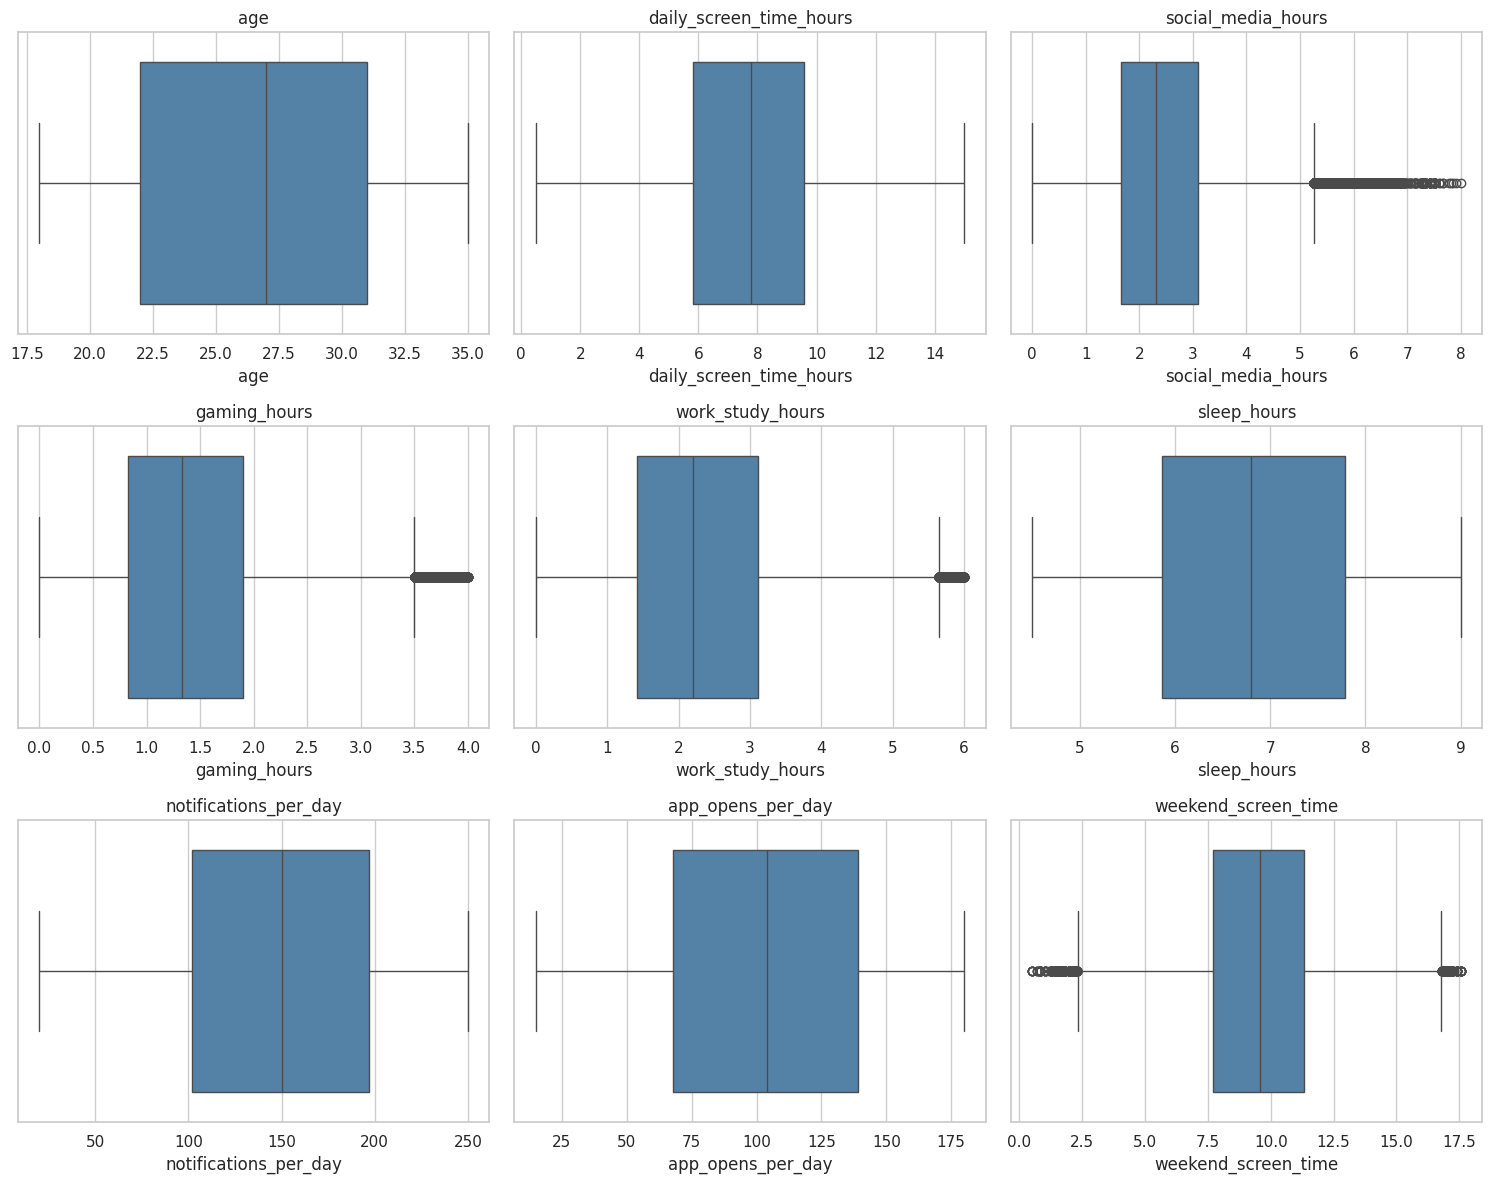

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=train_df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## 1.12. Validation Strategy Setup

In [28]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 1.13. Baseline Model — LightGBM

In [29]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

engineered = ['screen_time_diff', 'total_logged_hours', 'social_share', 'recreation_to_work', 'weekend_intensity']
missing_flag_cols = [f'{c}_was_missing' for c in num_cols + cat_cols]
features = num_cols + engineered + missing_flag_cols

X = train_df[features + cat_cols].copy()
for c in cat_cols:
    X[c] = X[c].astype('category')
y = train_df['addicted_label']

oof_preds = np.zeros(len(X))
models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    models.append(model)
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

print(f"\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.5f}")

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3255
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.229283
Fold 0 AUC: 0.96094
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.121714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you ca

## 1.14. Feature Importance

/tmp/ipykernel_1620/1384829967.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


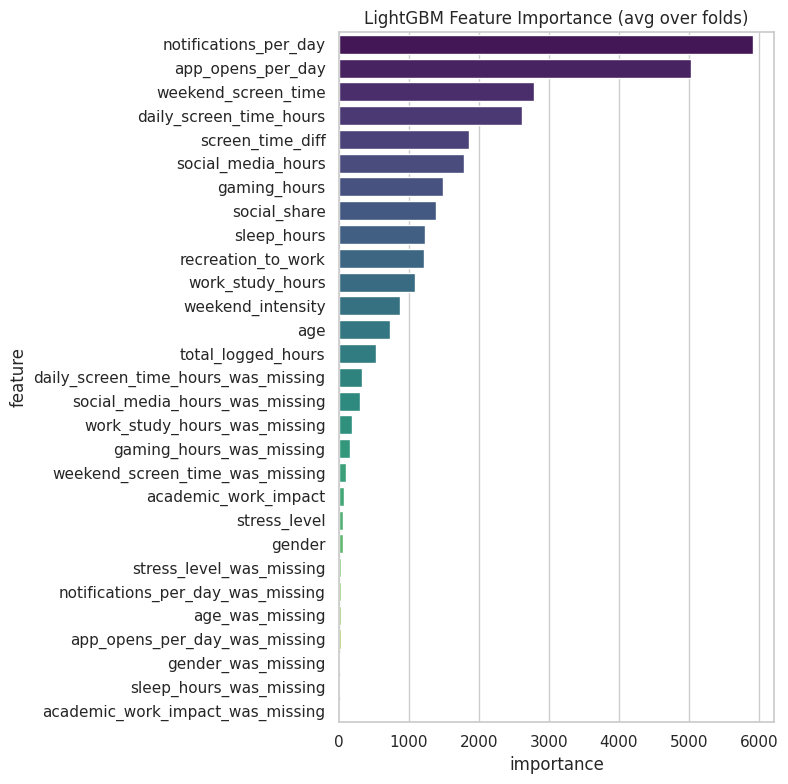

In [30]:
importance_df = pd.DataFrame({
    'feature': features + cat_cols,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('LightGBM Feature Importance (avg over folds)')
plt.tight_layout()
plt.show()

## 1.15. Diagnosis — Early Stopping Never Triggered

In [31]:
# All 5 folds hit the 1000-iteration cap without early stopping — model likely still improving.
# Also notice notifications_per_day and app_opens_per_day are now the TOP features by importance,
# despite near-zero linear correlation with target (0.00 and 0.06) — this points to a threshold/nonlinear
# effect (e.g. addicted_label may be partly rule-generated from these, common in synthetic playground data).
# Check for a clear split point.
for col in ['notifications_per_day', 'app_opens_per_day']:
    print(f"\n{col} by addicted_label:")
    print(train_df.groupby('addicted_label')[col].describe()[['mean', '50%', 'min', 'max']])


notifications_per_day by addicted_label:
                      mean    50%   min    max
addicted_label                                
0               147.371552  150.0  20.0  250.0
1               145.855727  150.0  20.0  250.0

app_opens_per_day by addicted_label:
                      mean    50%   min    max
addicted_label                                
0                98.578606  104.0  15.0  180.0
1               104.523308  104.0  15.0  180.0


## 1.16. Check for Threshold Rule in Top Features

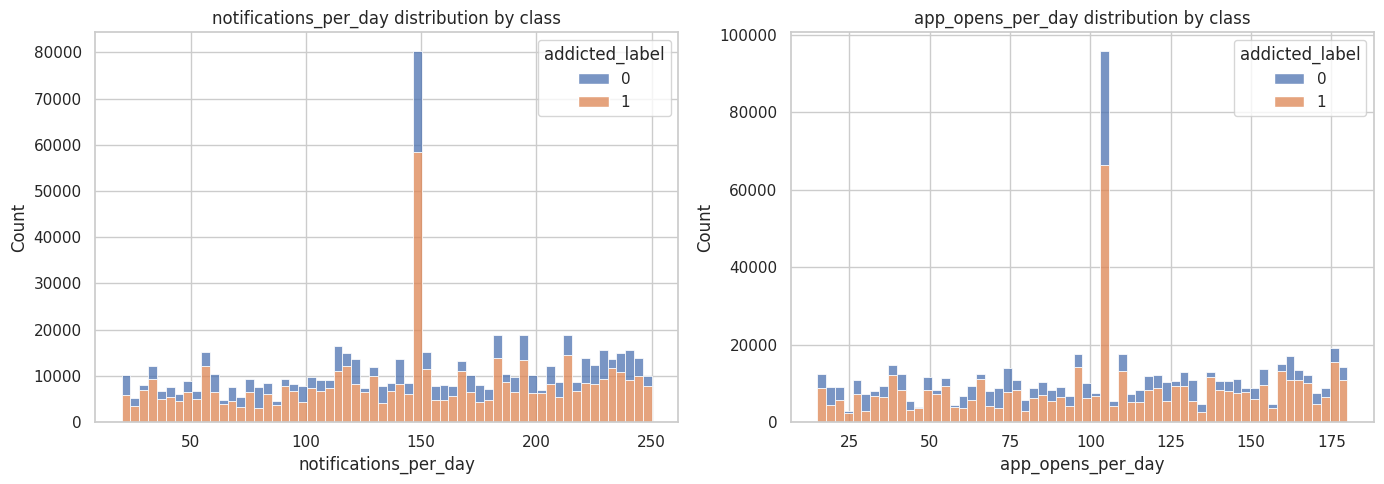

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(['notifications_per_day', 'app_opens_per_day']):
    sns.histplot(data=train_df, x=col, hue='addicted_label', bins=60, kde=False, ax=axes[i], multiple='stack')
    axes[i].set_title(f'{col} distribution by class')
plt.tight_layout()
plt.show()

## 1.17. Re-run Baseline with More Trees and Patience

In [33]:
X = train_df[features + cat_cols].copy()
for c in cat_cols:
    X[c] = X[c].astype('category')
y = train_df['addicted_label']

oof_preds = np.zeros(len(X))
models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.02,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    models.append(model)
    print(f"Fold {fold} — best iter: {model.best_iteration_}, AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.5f}")

print(f"\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.5f}")

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.206682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3255
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4371]	valid_0's auc: 0.96341	valid_0's binary_logloss: 0.221266
Fold 0 — best iter: 4371, AUC: 0.96341
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And i

## 1.19. Drop Leaky/Low-Value Noise Features

In [34]:
# notifications_per_day and app_opens_per_day show near-identical means across classes —
# their importance is likely from spurious splits on the imputation spike, not real signal.
# Keep them in for now but flag for ablation; drop the _was_missing flags for categoricals with near-zero importance.
low_value_missing_flags = [c for c in missing_flag_cols if 'was_missing' in c and c not in
                            ['daily_screen_time_hours_was_missing', 'social_media_hours_was_missing']]
features_v2 = [f for f in features if f not in low_value_missing_flags]
print(f"Reduced from {len(features)} to {len(features_v2)} features")

Reduced from 26 to 16 features


## 2.1. Proper Train/Validation/Test Split

In [35]:
from sklearn.model_selection import train_test_split

# 70/15/15 split, stratified on target
X_full = train_df[features_v2 + cat_cols].copy()
y_full = train_df['addicted_label']

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.15, stratify=y_full, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42  # 0.1765*0.85 ≈ 0.15
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train target rate: {y_train.mean():.4f}, Val: {y_val.mean():.4f}, Test: {y_test.mean():.4f}")

Train: (483940, 19), Val: (103723, 19), Test: (103706, 19)
Train target rate: 0.7094, Val: 0.7094, Test: 0.7094


## 2.2. Encode Categoricals for sklearn Models (One-Hot)

In [36]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_val_cat = ohe.transform(X_val[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)

X_train_enc = pd.concat([
    X_train[features_v2].reset_index(drop=True),
    pd.DataFrame(X_train_cat, columns=ohe_cols)
], axis=1)
X_val_enc = pd.concat([
    X_val[features_v2].reset_index(drop=True),
    pd.DataFrame(X_val_cat, columns=ohe_cols)
], axis=1)
X_test_enc = pd.concat([
    X_test[features_v2].reset_index(drop=True),
    pd.DataFrame(X_test_cat, columns=ohe_cols)
], axis=1)

y_train_r = y_train.reset_index(drop=True)
y_val_r = y_val.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

print(X_train_enc.shape, X_val_enc.shape, X_test_enc.shape)

(483940, 27) (103723, 27) (103706, 27)
